# Tutorial to correlation for signal detection and timing

## Correlation background for timing applications

### Correlation function
Small math background how it's formulated
<font color ='red'> TODO </font>

## Timing-Jitter

### Correlation for detecting signal in AWGN

### Affects of Jitter on Timing problems
<font color ='red'> TODO </font>

### Other causes of Jitter (Beyond this tutorial's scope)
<font color ='red'> TODO </font>



###  Small introduction to blind detection:


#### Python imports
Prior to beginning this jupyter-notebook tutorial, we can include some python imports.

include the signature of a signal class

In [2]:
"""
IED (Interictal Epileptiform Discharge) Waveform Generator
Based on IFCN Criteria (Kural et al., Neurology 2020)
Simple class for generating synthetic IED waveforms with customizable parameters.
"""
import numpy as np
from dataclasses import dataclass
from typing import Optional

@dataclass
class IEDParams:
    """Parameters for generating an IED waveform"""

    # Spike component
    spike_amplitude: float = 150.0      # Microvolts (µV)
    spike_duration: float = 70.0        # Milliseconds (ms)
    rise_time: float = 20.0             # Time to peak (ms)
    fall_time: float = 50.0             # Time from peak (ms)
    sharpness: float = 2.0              # Higher = sharper peak

    # Slow wave component
    slow_wave_amplitude: float = 80.0   # µV (relative to spike)
    slow_wave_duration: float = 200.0   # ms

    # Background
    background_freq: float = 10.0       # Hz (e.g., alpha rhythm)
    background_amplitude: float = 50.0  # µV

    # Noise
    noise_level: float = 5.0            # µV

    # Polarity
    negative_spike: bool = True         # True for negative spike


class IEDWaveformGenerator:
    """
    Generate synthetic IED waveforms with customizable morphology.

    Example:
        >>> gen = IEDWaveformGenerator(sampling_rate=256)
        >>>
        >>> # Generate a typical sharp spike
        >>> params = IEDParams(spike_amplitude=150, rise_time=20, fall_time=50)
        >>> time, waveform = gen.generate(params, duration=1.0)
        >>>
        >>> # Generate a slower spike
        >>> params_slow = IEDParams(spike_amplitude=120, rise_time=40, fall_time=100)
        >>> time, waveform = gen.generate(params_slow, duration=1.0)
    """

    def __init__(self, sampling_rate: int = 256):
        """
        Args:
            sampling_rate: Sampling frequency in Hz (default: 256 Hz)
        """
        self.sampling_rate = sampling_rate

    def generate(self,
                 params: IEDParams,
                 duration: float = 1.0,
                 spike_time: Optional[float] = None) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate an IED waveform.

        Args:
            params: IED parameters
            duration: Total duration in seconds
            spike_time: Time of spike peak in seconds (default: middle of epoch)

        Returns:
            (time_array, waveform): Time points and corresponding voltage values
        """
        # Create time array
        n_samples = int(duration * self.sampling_rate)
        time = np.linspace(0, duration, n_samples)

        # Spike timing
        if spike_time is None:
            spike_time = duration / 2

        # Initialize waveform with background activity
        waveform = self._generate_background(time, params)

        # Add spike
        spike = self._generate_spike(time, spike_time, params)
        waveform += spike

        # Add slow wave
        slow_wave = self._generate_slow_wave(time, spike_time, params)
        waveform += slow_wave

        # Add noise
        noise = np.random.normal(0, params.noise_level, n_samples)
        waveform += noise

        return time, waveform

    def _generate_spike(self,
                       time: np.ndarray,
                       peak_time: float,
                       params: IEDParams) -> np.ndarray:
        """Generate the spike component"""
        spike = np.zeros_like(time)

        # Convert times to seconds
        rise_time_sec = params.rise_time / 1000.0
        fall_time_sec = params.fall_time / 1000.0

        # Rising phase (before peak)
        rising_mask = time < peak_time
        if np.any(rising_mask):
            t_rise = time[rising_mask]
            # Exponential rise with sharpness control
            spike[rising_mask] = params.spike_amplitude * np.exp(
                -((peak_time - t_rise) / rise_time_sec) ** params.sharpness
            )

        # Falling phase (after peak)
        falling_mask = time >= peak_time
        if np.any(falling_mask):
            t_fall = time[falling_mask]
            # Exponential decay
            spike[falling_mask] = params.spike_amplitude * np.exp(
                -((t_fall - peak_time) / fall_time_sec) ** (params.sharpness * 0.7)
            )

        # Apply polarity
        if params.negative_spike:
            spike = -spike

        return spike

    def _generate_slow_wave(self,
                           time: np.ndarray,
                           spike_time: float,
                           params: IEDParams) -> np.ndarray:
        """Generate the slow after-wave component"""
        slow_wave = np.zeros_like(time)

        # Slow wave starts after the spike
        slow_duration_sec = params.slow_wave_duration / 1000.0
        slow_start = spike_time + (params.fall_time / 1000.0)

        # Create slow wave (opposite polarity to spike)
        slow_mask = (time >= slow_start) & (time < slow_start + slow_duration_sec)
        if np.any(slow_mask):
            t_slow = time[slow_mask]
            # Gaussian-like slow wave
            center = slow_start + slow_duration_sec / 2
            sigma = slow_duration_sec / 4
            slow_wave[slow_mask] = params.slow_wave_amplitude * np.exp(
                -((t_slow - center) / sigma) ** 2
            )

            # Opposite polarity to spike
            if params.negative_spike:
                slow_wave[slow_mask] = slow_wave[slow_mask]
            else:
                slow_wave[slow_mask] = -slow_wave[slow_mask]

        return slow_wave

    def _generate_background(self,
                            time: np.ndarray,
                            params: IEDParams) -> np.ndarray:
        """Generate background EEG activity"""
        # Simple sinusoidal background (can be made more complex)
        background = params.background_amplitude * np.sin(
            2 * np.pi * params.background_freq * time
        )

        # Add some variation with harmonics
        background += 0.3 * params.background_amplitude * np.sin(
            2 * np.pi * params.background_freq * 2 * time + 0.5
        )

        return background

    def generate_multi_channel(self,
                              params: IEDParams,
                              n_channels: int = 4,
                              duration: float = 1.0,
                              amplitude_decay: float = 0.7) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate multi-channel IED (simulating spatial propagation).

        Args:
            params: IED parameters
            n_channels: Number of channels
            duration: Duration in seconds
            amplitude_decay: Amplitude decay per channel (0-1)

        Returns:
            (time_array, waveforms): Time and array of shape (n_samples, n_channels)
        """
        time, waveform = self.generate(params, duration)

        # Create multiple channels with decreasing amplitude
        waveforms = np.zeros((len(time), n_channels))
        for i in range(n_channels):
            channel_params = IEDParams(**params.__dict__)
            channel_params.spike_amplitude *= (amplitude_decay ** i)
            channel_params.slow_wave_amplitude *= (amplitude_decay ** i)

            # Add slight time delay for propagation effect
            spike_time = (duration / 2) + (i * 0.005)  # 5ms delay per channel
            _, waveforms[:, i] = self.generate(channel_params, duration, spike_time)

        return time, waveforms


In [3]:
# Preset configurations for common IED types
PRESET_SHARP_SPIKE = IEDParams(
    spike_amplitude=150,
    rise_time=15,
    fall_time=40,
    sharpness=2.5,
    slow_wave_amplitude=80,
    slow_wave_duration=200
)

PRESET_BLUNT_SPIKE = IEDParams(
    spike_amplitude=120,
    rise_time=40,
    fall_time=100,
    sharpness=1.5,
    slow_wave_amplitude=60,
    slow_wave_duration=250
)

PRESET_SHARP_WAVE = IEDParams(
    spike_amplitude=100,
    rise_time=50,
    fall_time=150,
    sharpness=1.2,
    slow_wave_amplitude=50,
    slow_wave_duration=300
)

PRESET_SPIKE_WAVE = IEDParams(
    spike_amplitude=180,
    rise_time=20,
    fall_time=60,
    sharpness=2.0,
    slow_wave_amplitude=120,
    slow_wave_duration=250
)


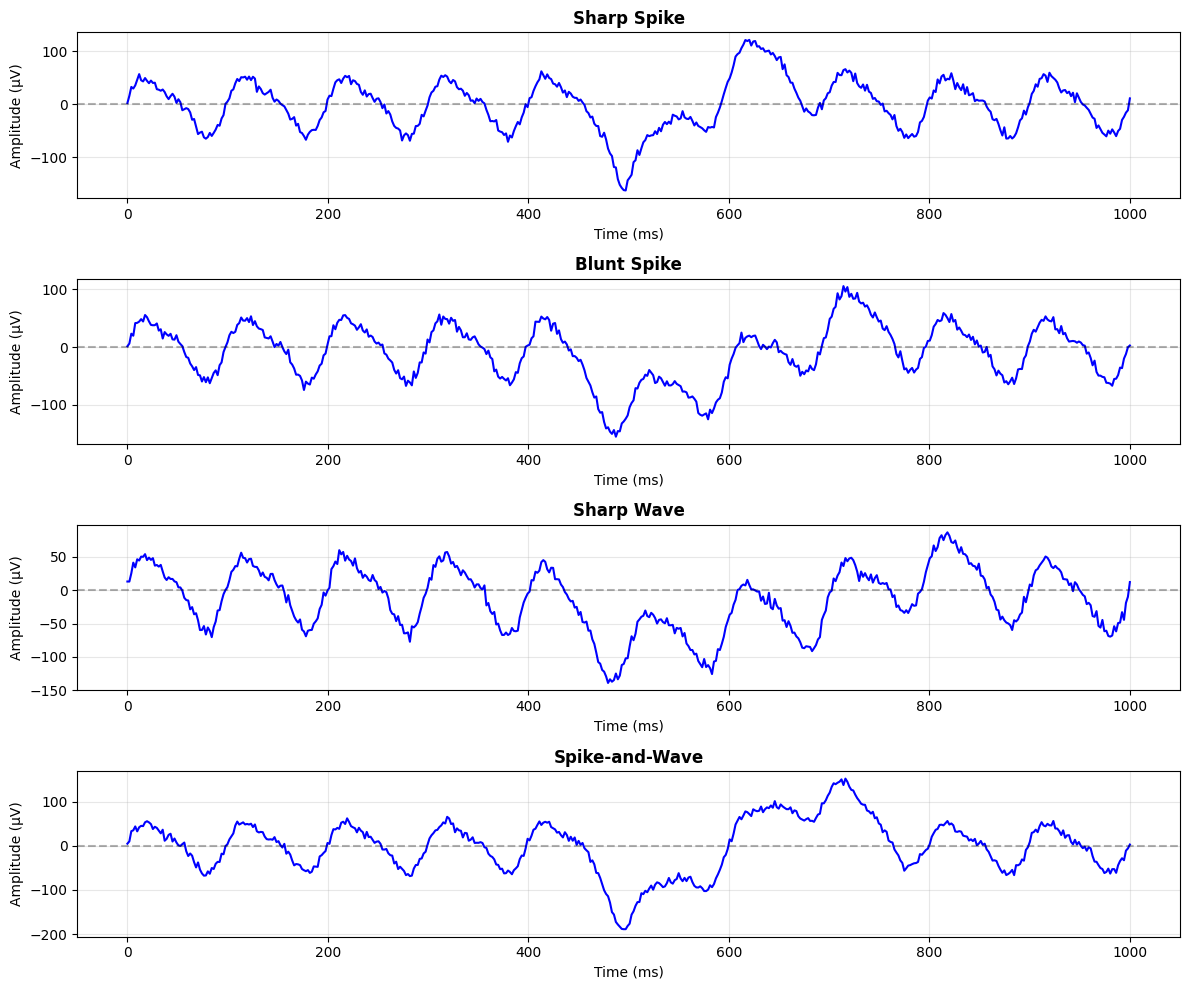

In [5]:
# Example usage
import matplotlib.pyplot as plt

gen = IEDWaveformGenerator(sampling_rate=512)

# Generate different IED types
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

presets = [
    ("Sharp Spike", PRESET_SHARP_SPIKE),
    ("Blunt Spike", PRESET_BLUNT_SPIKE),
    ("Sharp Wave", PRESET_SHARP_WAVE),
    ("Spike-and-Wave", PRESET_SPIKE_WAVE)
]

for ax, (name, params) in zip(axes, presets):
    time, waveform = gen.generate(params, duration=1.0)
    ax.plot(time * 1000, waveform, 'b-', linewidth=1.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (µV)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Solutions

Autocorrelation - Why?  
Correlation - typical attempt  
Ambiguity function? - correlation in 2D, where 1 is delays, other is some other such as "doppler, freq, or another variable"  

